In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import AveragePooling2D


In [11]:
data = pd.read_csv(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data\Images110.csv')

In [12]:
data.head()

,label,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p36290,p36291,p36292,p36293,p36294,p36295,p36296,p36297,p36298,p36299
0,0,232,240,223,232,240,223,231,239,222,...,130,86,107,134,89,110,137,94,115,142
1,0,225,250,254,229,248,254,229,248,255,...,199,162,191,200,159,190,199,159,190,199
2,0,165,154,122,173,152,120,172,150,122,...,109,23,88,126,21,90,127,19,90,130
3,0,197,197,173,198,202,176,199,201,178,...,78,5,82,85,3,78,80,3,85,86
4,0,218,219,181,235,224,176,228,214,178,...,208,147,204,220,138,195,210,143,203,218


In [14]:
Y_raw = data.iloc[:, 0].values
X_flat = data.iloc[:, 1:].values.astype('float32')


In [15]:
expected = 110 * 110 * 3
if X_flat.shape[1] != expected:
    raise ValueError(f"Expected {expected} columns for image pixels, found {X_flat.shape[1]}")

X = X_flat.reshape(-1, 110, 110, 3) / 255.0  # normalize to [0,1]


In [16]:
# encode labels and convert to one-hot
le = LabelEncoder()
Y_enc = le.fit_transform(Y_raw)
n_classes = len(np.unique(Y_enc))
Y = to_categorical(Y_enc, n_classes)


In [17]:
# train/test split (stratify to keep class balance)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=30, stratify=Y_enc)


# Build CNN with 2 Conv + 2 MaxPool layers

c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 110, 110, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 55, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     5,972,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,991,875 (22.86 MB)

 Trainable params: 5,991,875 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.6858 - loss: 0.6819 - val_accuracy: 0.9497 - val_loss: 0.1384
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.9522 - loss: 0.1595 - val_accuracy: 0.9356 - val_loss: 0.2271
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.9250 - loss: 0.2211 - val_accuracy: 0.9718 - val_loss: 0.0762
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9693 - loss: 0.0870 - val_accuracy: 0.9839 - val_loss: 0.0456
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.9839 - loss: 0.0531 - val_accuracy: 0.9859 - val_loss: 0.0395
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9839 - loss: 0.0566 - val_accuracy: 0.9859 - val_loss: 0.0327
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - accuracy: 0.9924 - loss: 0.0229 - val_accuracy: 0.9879 - val_loss: 0.0234
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - accuracy: 0.9919 - loss: 0.0180 - val_accu

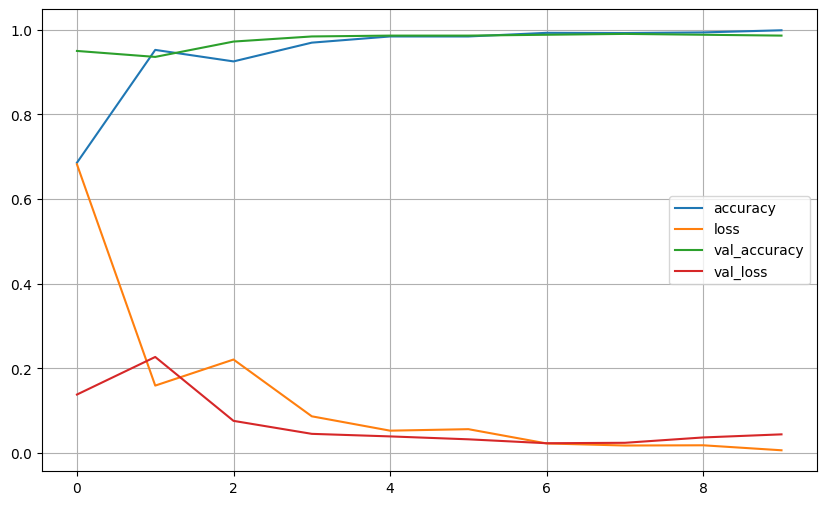

In [19]:

cnn = Sequential([
    # First Conv + MaxPool block
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(110,110,3)),
    MaxPooling2D((2,2)),
    
    # Second Conv + MaxPool block 
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])
cnn.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

# train and save history
history = cnn.fit(X_train, Y_train, validation_data=(X_test, Y_test),
                  epochs=10, batch_size=32, verbose=1)

# evaluate
train_res = cnn.evaluate(X_train, Y_train, verbose=0)
test_res = cnn.evaluate(X_test, Y_test, verbose=0)
print('Train loss =', train_res[0], 'Train accuracy =', train_res[1])
print('Test  loss =', test_res[0],  'Test  accuracy =', test_res[1])

# plot metrics
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.grid(True)
plt.show()

# save model
cnn.save(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\CNN__model.keras')

# Build CNN with 2 Conv + 2 AveragePool layers

c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 110, 110, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 55, 55, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 55, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 27, 27, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,972,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,991,875 (22.86 MB)

 Trainable params: 5,991,875 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - accuracy: 0.6913 - loss: 0.7061 - val_accuracy: 0.7344 - val_loss: 0.6962
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - accuracy: 0.8102 - loss: 0.5005 - val_accuracy: 0.8873 - val_loss: 0.3321
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.8686 - loss: 0.3511 - val_accuracy: 0.9175 - val_loss: 0.2152
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.8973 - loss: 0.2831 - val_accuracy: 0.9577 - val_loss: 0.1320
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step - accuracy: 0.9512 - loss: 0.1455 - val_accuracy: 0.9799 - val_loss: 0.0588
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9637 - loss: 0.1133 - val_accuracy: 0.9839 - val_loss: 0.0509
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.9617 - loss: 0.1021 - val_accuracy: 0.9799 - val_loss: 0.0495
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9768 - loss: 0.0666 - val_accu

<Figure size 1000x600 with 0 Axes>

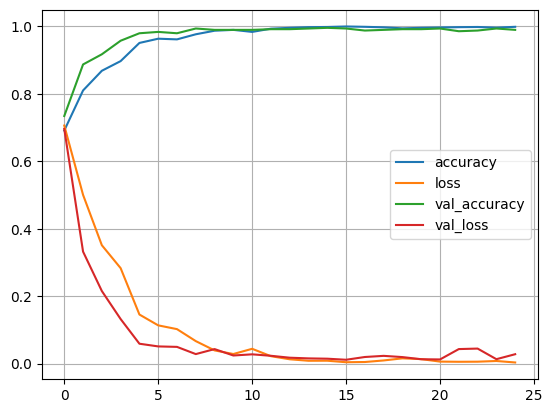

In [18]:

cnn = Sequential([
    # First Conv + AveragePool block
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(110,110,3)),
    AveragePooling2D((2,2)),
    
    # Second Conv + AveragePool block 
    Conv2D(64, (3,3), activation='relu', padding='same'),
    AveragePooling2D((2,2)),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

# Compile model
cnn.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

cnn.summary()

# Train model
history = cnn.fit(X_train, Y_train, 
                 validation_data=(X_test, Y_test),
                 epochs=25,
                 batch_size=32, 
                 verbose=1)

# Evaluate
train_res = cnn.evaluate(X_train, Y_train, verbose=0)
test_res = cnn.evaluate(X_test, Y_test, verbose=0)
print('Train loss =', train_res[0], 'Train accuracy =', train_res[1])
print('Test  loss =', test_res[0], 'Test  accuracy =', test_res[1])

# Plot metrics
plt.figure(figsize=(10,6))
pd.DataFrame(history.history).plot()
plt.grid(True)
plt.show()

# Save model
cnn.save(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\CNN_AVG_model.keras')